In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("CH_data2023.csv", encoding="Latin1")

In [15]:
# df.info()
# Plot as a bar chart states by number of incidents
df["source"].unique()

array(['Medical Examiner and Coroner', 'Consumer',
       'Other Clipping Service', 'Public Safety Entity',
       'Online News Sources', 'State Government Agency',
       'Health Care Professional', 'Federal Government Agency',
       'Local Government Agency', 'Death Certificates',
       'Child Service Provider'], dtype=object)

In [17]:
df["state"] = df["state"].fillna("No Info")

<BarContainer object of 53 artists>

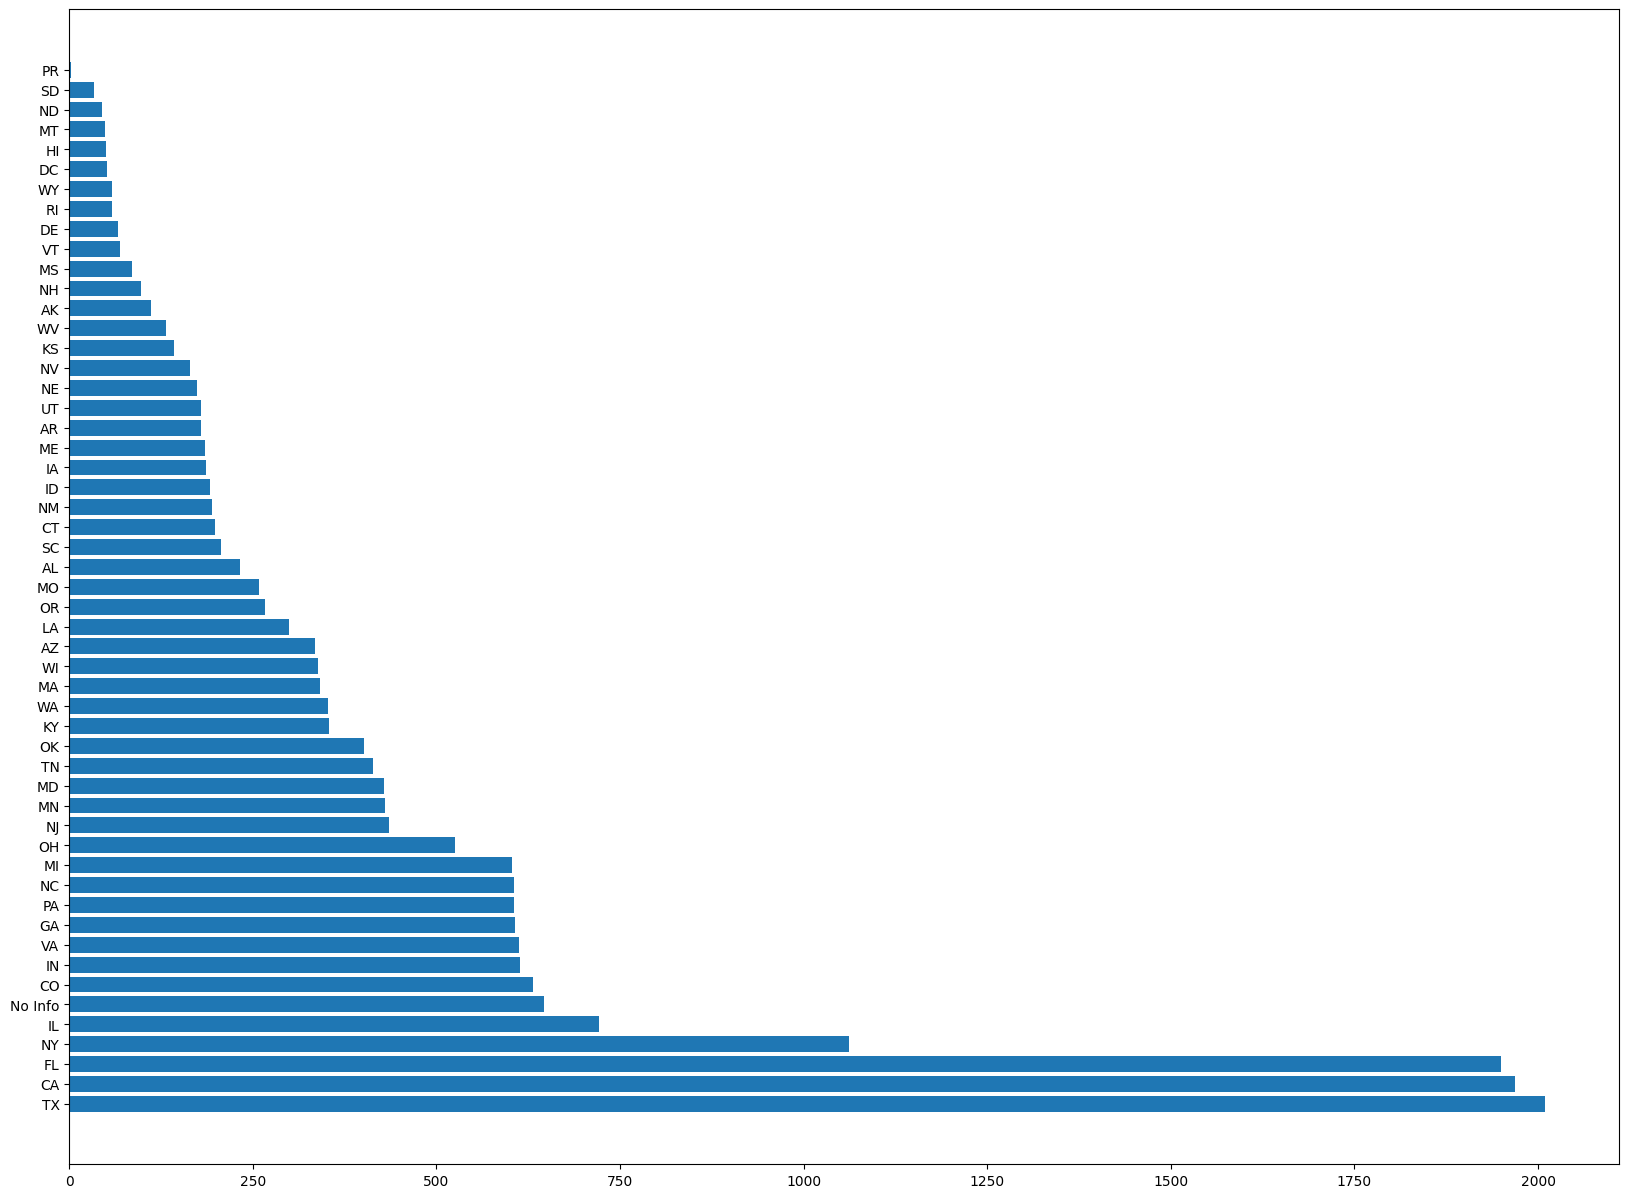

In [21]:
states  = df["state"].value_counts()
plt.figure(figsize=(20,15))
plt.barh(states.index, states);
# 1. filter for Death Certificate
# 2. Plot as a bar chart filtered data

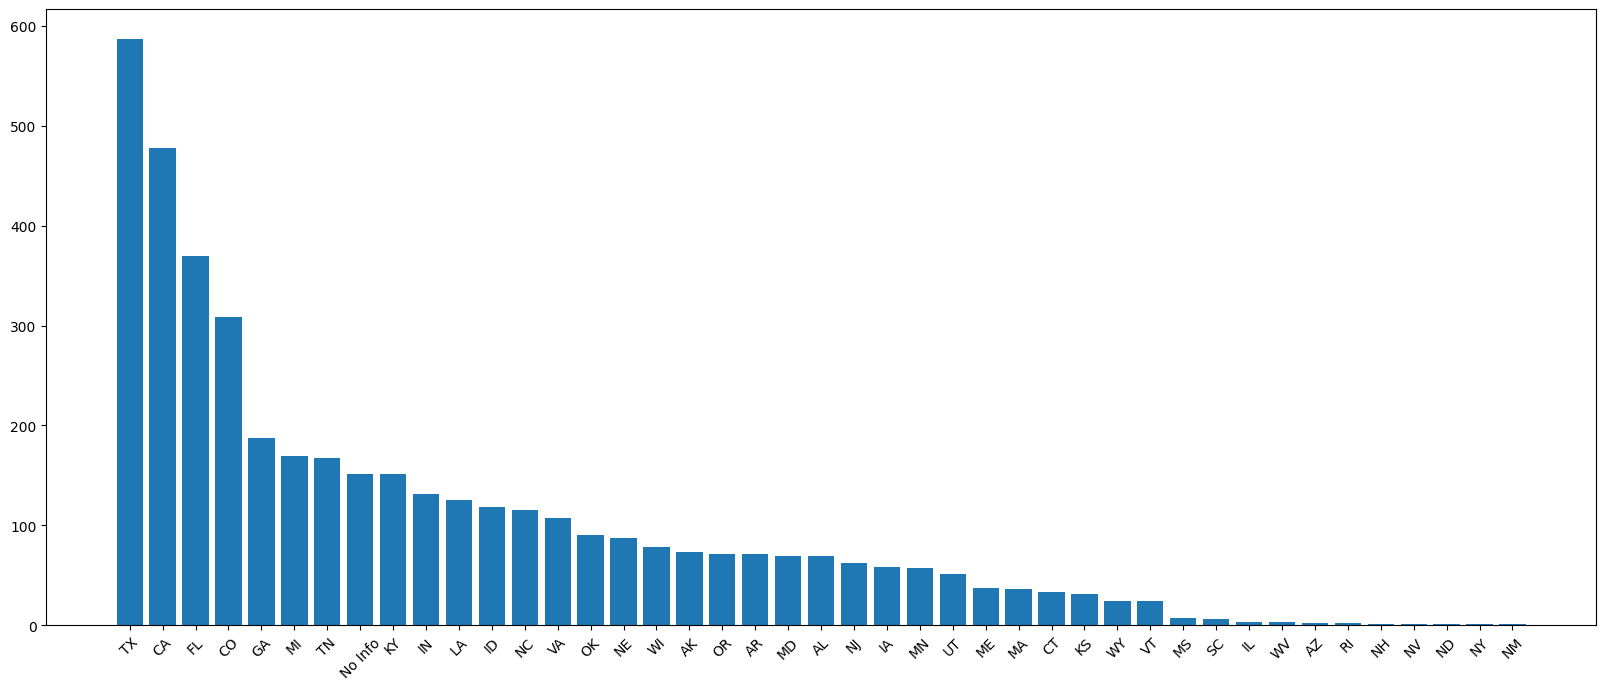

In [32]:
# 1. filter for Death Certificate
# 2. Plot as a bar chart filtered data
dc = df[df["source"] == "Death Certificates"]
dc_state = dc['state'].value_counts()
plt.figure(figsize=(20,8))
plt.bar(dc_state.index, dc_state)
plt.xticks(rotation=45);

In [34]:
df.columns

Index(['incident_id', 'received_year', 'received_month', 'source', 'state',
       'incident_year', 'incident_month', 'external_cause', 'product_1',
       'product_1_hazard', 'product_2', 'product_2_hazard', 'product_3',
       'product_3_hazard', 'victim_1_sex', 'victim_1_age_years',
       'victim_1_age_months', 'victim_1_injury', 'victim_1_body_part',
       'victim_1_severity', 'victim_2_sex', 'victim_2_age_years',
       'victim_2_age_months', 'victim_2_injury', 'victim_2_body_part',
       'victim_2_severity', 'victim_3_sex', 'victim_3_age_years',
       'victim_3_age_months', 'victim_3_injury', 'victim_3_body_part',
       'victim_3_severity', 'incident_description'],
      dtype='object')

Text(0, 0.5, 'Count')

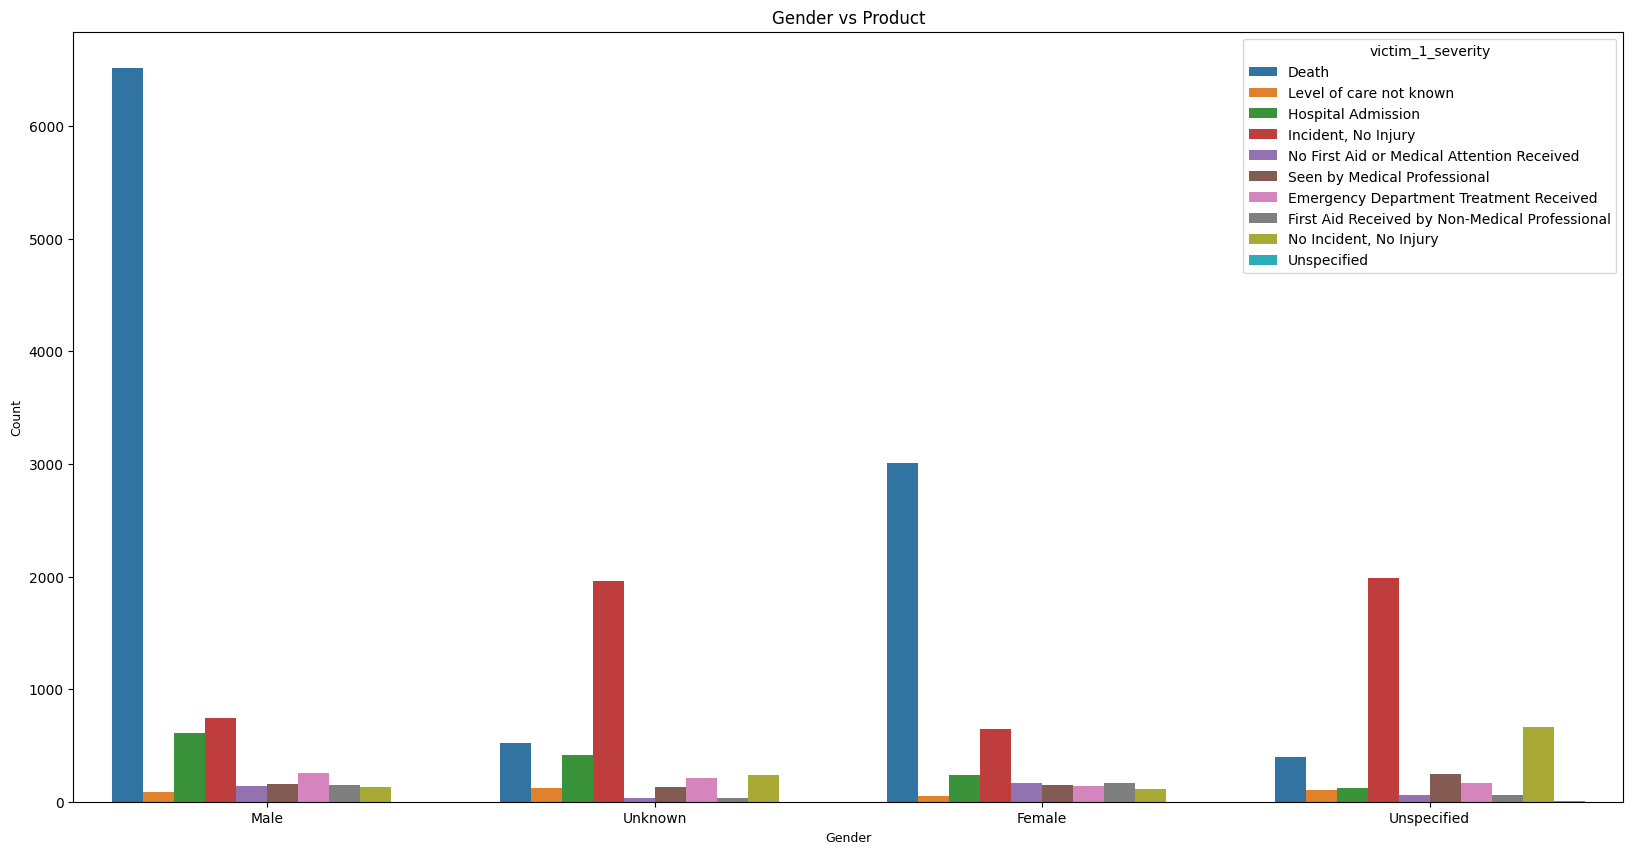

In [38]:
df["victim_1_sex"]
plt.figure(figsize=(20,10))
sns.countplot(x="victim_1_sex", hue="victim_1_severity",data=df)
plt.title('Gender vs Product')
plt.xlabel('Gender', fontsize=9)
plt.ylabel('Count',fontsize=9)

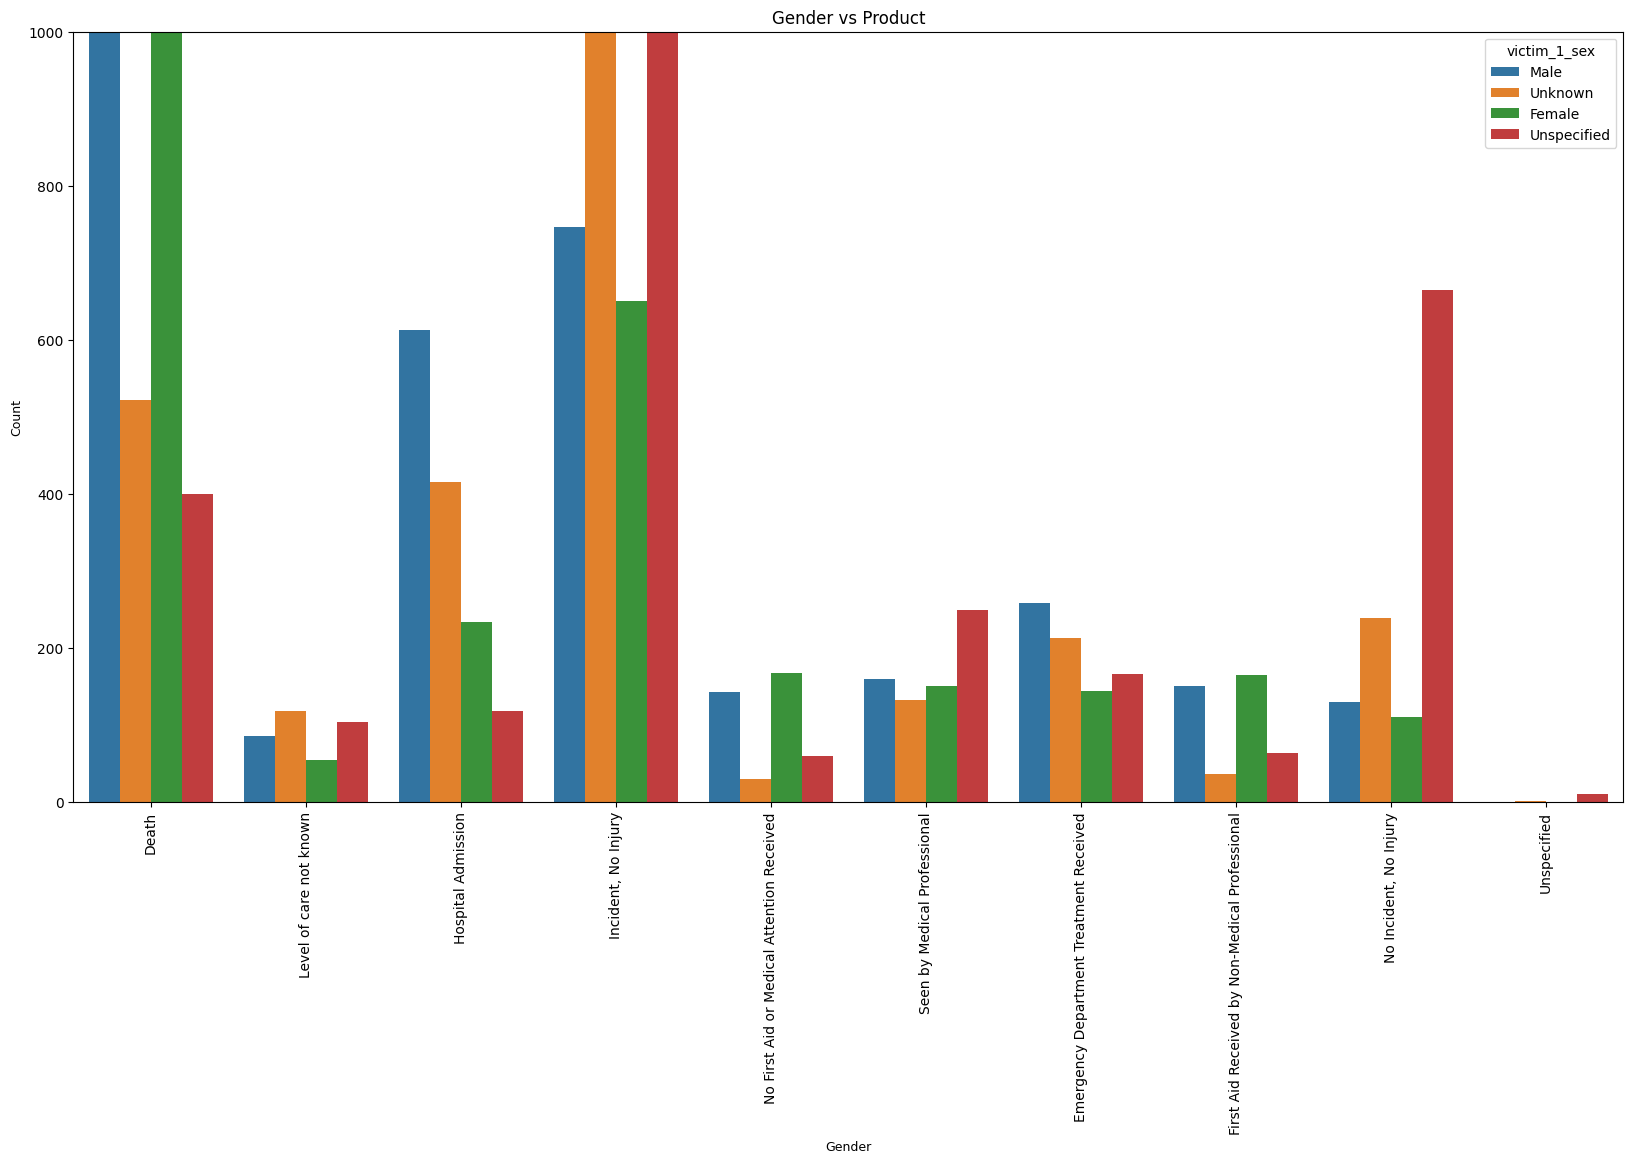

In [45]:
df["victim_1_sex"]
plt.figure(figsize=(20,10))
sns.countplot(x="victim_1_severity", hue="victim_1_sex",data=df)
plt.title('Gender vs Product')
plt.xlabel('Gender', fontsize=9)
plt.ylabel('Count',fontsize=9)
plt.ylim(0,1000)
plt.xticks(rotation=90);

<Axes: xlabel='received_month'>

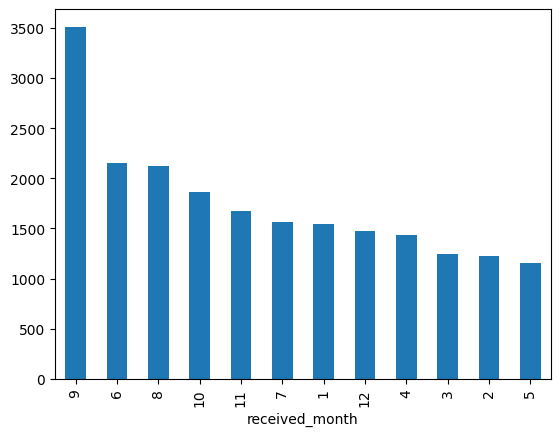

In [49]:
df['received_month'].value_counts().plot(kind="bar")

In [51]:
df["victim_1_severity"].unique()

array(['Death', 'Level of care not known', 'Hospital Admission',
       'Incident, No Injury',
       'No First Aid or Medical Attention Received',
       'Seen by Medical Professional',
       'Emergency Department Treatment Received',
       'First Aid Received by Non-Medical Professional',
       'No Incident, No Injury', 'Unspecified', nan], dtype=object)

In [52]:
df.groupby("victim_1_severity")['incident_id'].count()

victim_1_severity
Death                                             10443
Emergency Department Treatment Received             781
First Aid Received by Non-Medical Professional      413
Hospital Admission                                 1378
Incident, No Injury                                5337
Level of care not known                             361
No First Aid or Medical Attention Received          399
No Incident, No Injury                             1143
Seen by Medical Professional                        691
Unspecified                                          11
Name: incident_id, dtype: int64

In [53]:
df.groupby(["victim_1_severity",'received_month'])['incident_id'].count()

victim_1_severity  received_month
Death              1                 609
                   2                 388
                   3                 418
                   4                 480
                   5                 388
                                    ... 
Unspecified        3                   1
                   4                   2
                   6                   1
                   9                   1
                   11                  3
Name: incident_id, Length: 115, dtype: int64

In [55]:
cat = ["Death", "Hospital Admission"]
vs = df.query("victim_1_severity in @cat").copy()

<Axes: xlabel='state'>

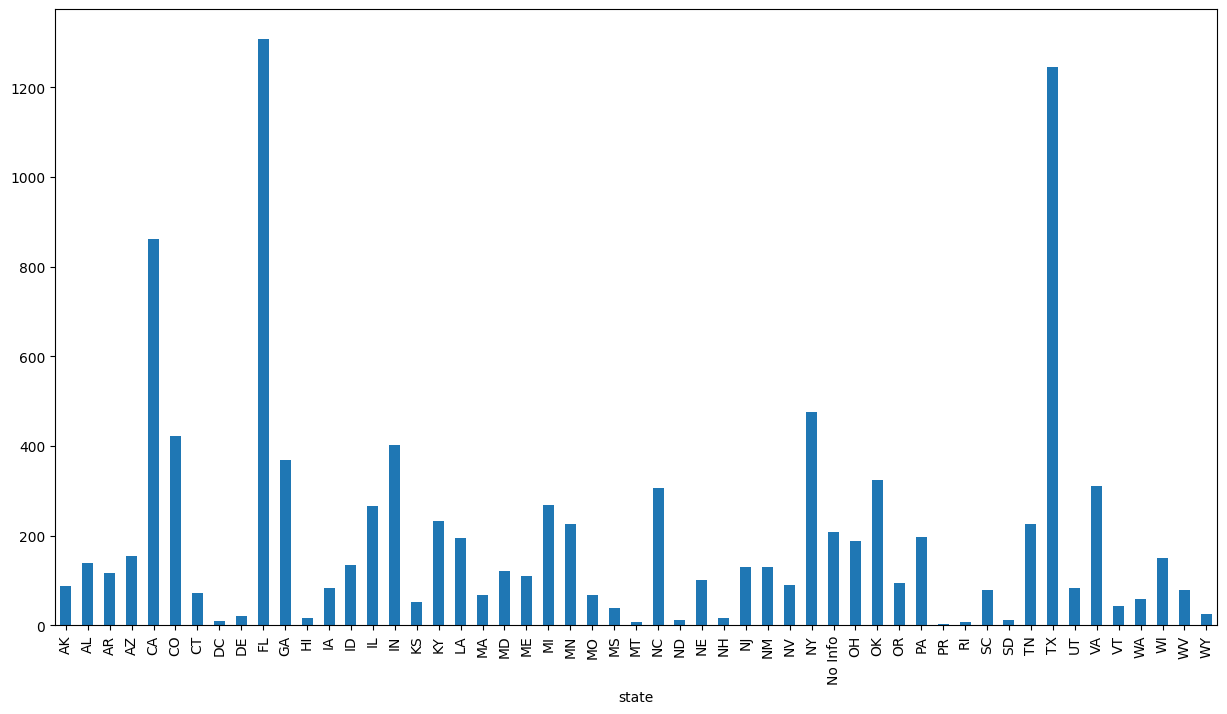

In [59]:
vs_state = vs.groupby(["victim_1_severity","state"])["incident_id"].count()
plt.figure(figsize=(15,8))
vs_state.loc["Death"].plot(kind="bar")